In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# 1. Đọc dữ liệu
df = pd.read_csv('melb_data.csv')
print(df.shape)

# 2. Drop những cột không dùng đến
df_cleaned = df.drop(columns=[
"Address",
"Propertycount",
"Method",
"SellerG",
"Postcode",
"CouncilArea"])

# 3. Kiểm tra và xử lý dữ liệu thiếu 
null_count = df_cleaned.isnull().sum()
null_percent = (df_cleaned.isnull().mean() * 100).round(3)
missing_values = pd.DataFrame({
    'Số lượng null': null_count,
    'Phần trăm null (%)': null_percent})
print("Tỉ lệ giá trị thiếu trong mỗi cột:")
print(missing_values)

df_cleaned = df_cleaned.drop(columns = ["BuildingArea", "YearBuilt"]) #Những cột thiếu khoảng từ 40%
df_cleaned = df_cleaned.dropna() #Các cột còn lại thiếu không quá 0.5%
print("Đã xử lý missing values")

# 4. Xử lý dữ liệu bất hợp lý
Handled_columns = ["Rooms", "Price", "Landsize"]
for col in Handled_columns:
    df_cleaned = df_cleaned[df_cleaned[col] > 0]
print("Đã xử lý dữ liệu bất hợp lý")


# 5. Kiểm tra và xử lý dữ liệu trùng lặp 
duplicates = df_cleaned.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp: {duplicates}")
df_cleaned = df_cleaned.drop_duplicates()
print("Đã xử lý trùng lặp")


# 6. Thay đổi kiểu dữ liệu nguyên, date, tạo biến month, year nhằm phân tích theo tháng, năm:
int_cols = ["Rooms", "Bedroom2", "Bathroom", "Car"]
for col in int_cols:
    df_cleaned[col] = df_cleaned[col].astype(int)

df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], dayfirst=True)
df_cleaned["year"] = df_cleaned["Date"].dt.year
df_cleaned["month"] = df_cleaned["Date"].dt.month

(13580, 21)
Tỉ lệ giá trị thiếu trong mỗi cột:
              Số lượng null  Phần trăm null (%)
Suburb                    0               0.000
Rooms                     0               0.000
Type                      0               0.000
Price                     0               0.000
Date                      0               0.000
Distance                  0               0.000
Bedroom2                  0               0.000
Bathroom                  0               0.000
Car                      62               0.457
Landsize                  0               0.000
BuildingArea           6450              47.496
YearBuilt              5375              39.580
Lattitude                 0               0.000
Longtitude                0               0.000
Regionname                0               0.000
Đã xử lý missing values
Đã xử lý dữ liệu bất hợp lý
Số lượng bản ghi trùng lặp: 1
Đã xử lý trùng lặp


In [2]:
# 7. Xử lý Suburb và Regionname:
# Đưa những khu vực (Suburb) với không quá 10 giao dịch BĐS thành nhóm Other
Surburb_stats=df_cleaned['Suburb'].value_counts(ascending=False)
Suburb_stats_less_than_10= Surburb_stats[Surburb_stats<=10]
print("Số lượng khu vực với không quá 10 giao dịch: ", len(Suburb_stats_less_than_10))
df_cleaned.Suburb=df_cleaned.Suburb.apply(lambda x:'Other' if x in Suburb_stats_less_than_10 else x)
print("Số lượng khu vực sau khi xử lý: ", len(df_cleaned["Suburb"].unique()), '\n')

# Xem số dòng ứng với từng giá trị của Regionnam
print(df_cleaned.groupby('Regionname')['Price'].count())
# drop những dòng có giá trị hiếm (e.g Eastern Victoria (52), Northern Victoria (40), Western Victoria(32))
dropped_region = ['Eastern Victoria', 'Northern Victoria', 'Western Victoria']
df_cleaned = df_cleaned[~df_cleaned['Regionname'].isin(dropped_region)]


# 8. Mã hóa dữ liệu phân loại (Type, Suburb, Regionname)
#Đối với Suburb ta sẽ dùng target encoding tại bước 6
#Đối với Type
dummy_variable1 = pd.get_dummies(df_cleaned["Type"])
dummy_variable1.rename(columns={'h':'Type_h', 't':'Type_t', 'u': 'Type_u'}, inplace=True)
df_cleaned = pd.concat([df_cleaned, dummy_variable1], axis=1)

#Đối với Regionname
dummy_variable2 = pd.get_dummies(df_cleaned["Regionname"])
dummy_variable2.rename(columns={'Northern Metropolitan':'Region_NM',
                                'Western Metropolitan':'Region_WM',
                                'Southern Metropolitan': 'Region_SM',
                                'Eastern Metropolitan': 'Region_EM',
                                'South-Eastern Metropolitan': 'Region_SEM'
                                }, inplace=True)
df_cleaned = pd.concat([df_cleaned, dummy_variable2], axis=1)

Số lượng khu vực với không quá 10 giao dịch:  111
Số lượng khu vực sau khi xử lý:  202 

Regionname
Eastern Metropolitan          1422
Eastern Victoria                52
Northern Metropolitan         3285
Northern Victoria               40
South-Eastern Metropolitan     438
Southern Metropolitan         3631
Western Metropolitan          2678
Western Victoria                32
Name: Price, dtype: int64


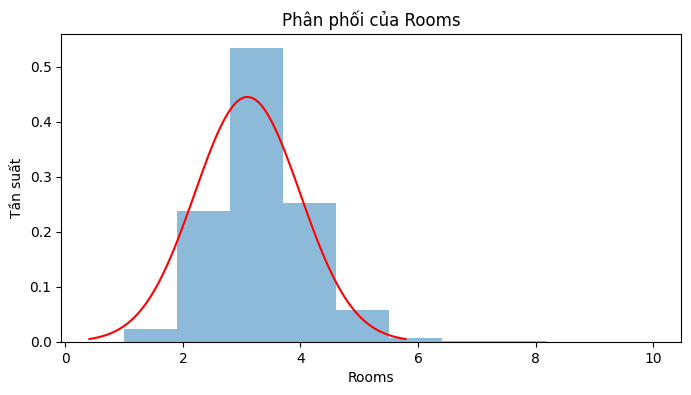

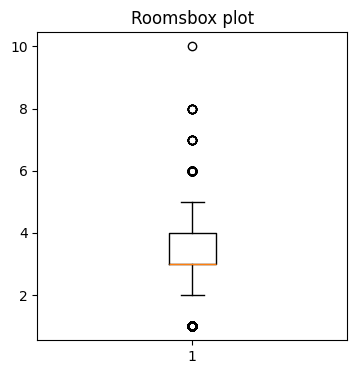

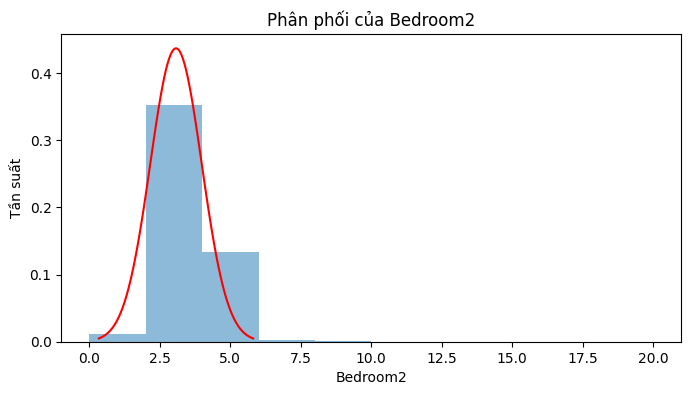

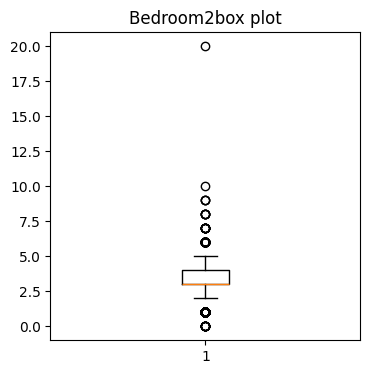

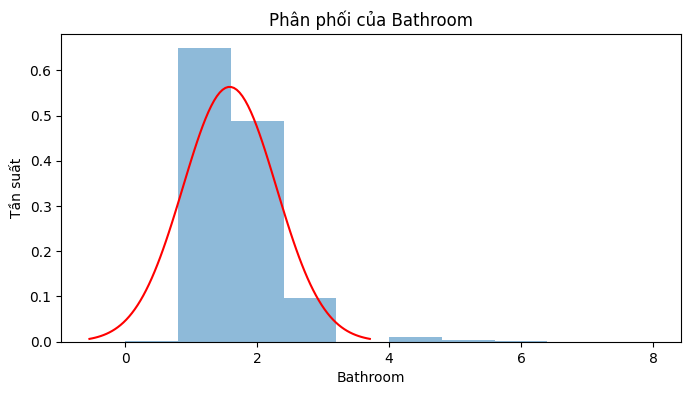

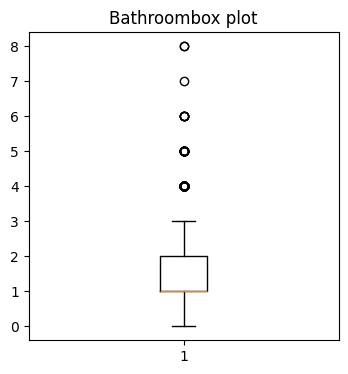

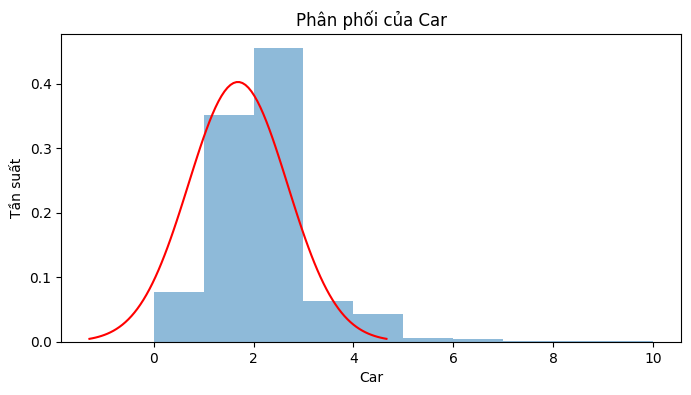

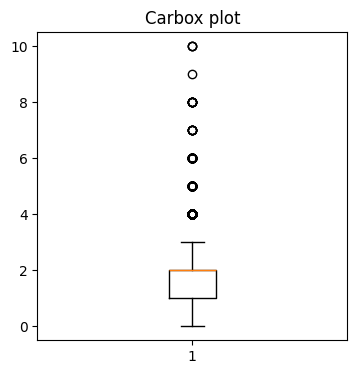

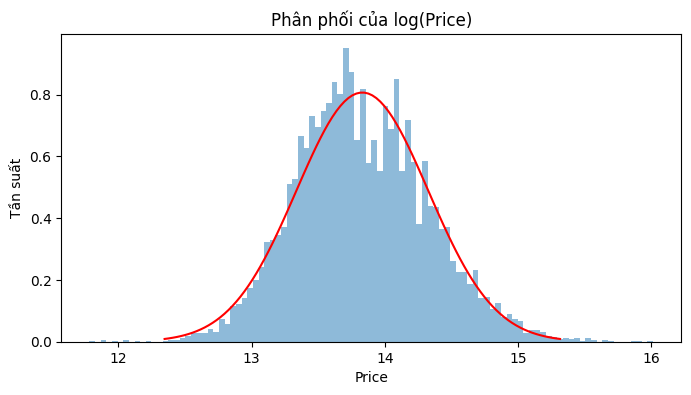

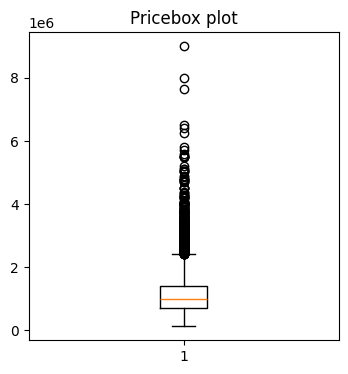

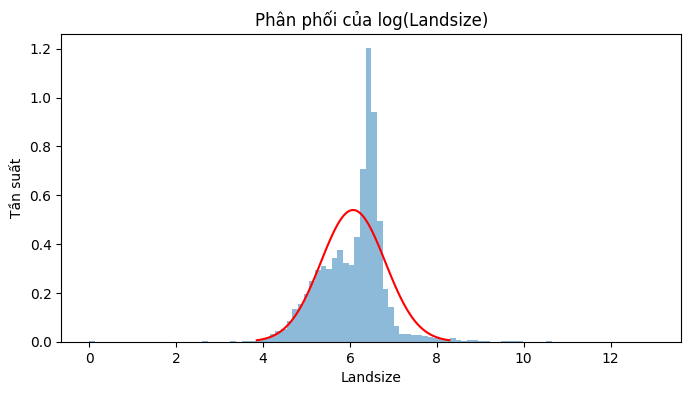

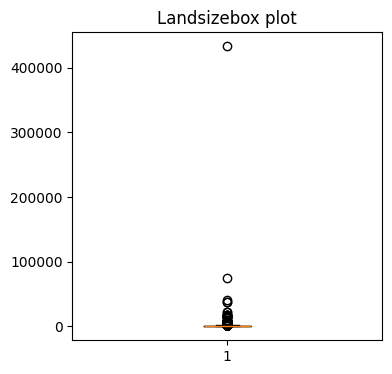

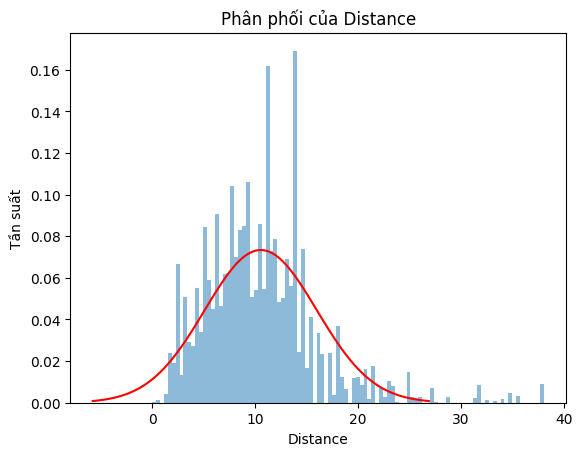

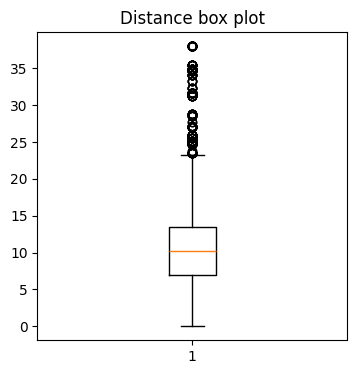

In [3]:
#Để loại bỏ outlier, ta xem phân phối của các cột số liệu

numeric_columns1 = ['Rooms', 'Bedroom2', 'Bathroom', 'Car']
numeric_columns2 = ['Price', 'Landsize']

for col in numeric_columns1:
    # Vẽ biểu đồ histogram
    plt.figure(figsize=(8, 4))
    plt.hist(df_cleaned[col], bins=10, density=True, alpha=0.5)

    # Vẽ biểu đồ bell curve
    mean = np.mean(df_cleaned[col])
    std = np.std(df_cleaned[col])
    x = np.linspace(mean - 3*std, mean + 3*std, 100)
    y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
    plt.plot(x, y, color='r')

    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.title('Phân phối của ' + col )
    plt.show()

    #vẽ box plot
    plt.figure(figsize=(4,4))
    plt.boxplot(df_cleaned[col])
    plt.title(col + 'box plot')
    plt.show()
  

for col in numeric_columns2:
    # Vẽ biểu đồ histogram
    plt.figure(figsize=(8, 4))
    plt.hist(np.log(df_cleaned[col]), bins=100, density=True, alpha=0.5)

    # Vẽ biểu đồ bell curve
    mean = np.mean(np.log(df_cleaned[col]))
    std = np.std(np.log(df_cleaned[col]))
    x = np.linspace(mean - 3*std, mean + 3*std, 100)
    y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
    plt.plot(x, y, color='r')

    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.title('Phân phối của log(' + col + ')')
    plt.show()

    #vẽ box plot
    plt.figure(figsize=(4,4))
    plt.boxplot(df_cleaned[col])
    plt.title(col + 'box plot')
    plt.show()


# Vẽ biểu đồ histogram
plt.hist(df_cleaned["Distance"], bins=100, density=True, alpha=0.5)

# Vẽ biểu đồ bell curve
mean = np.mean(df_cleaned["Distance"])
std = np.std(df_cleaned["Distance"])
x = np.linspace(mean - 3*std, mean + 3*std, 100)
y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
plt.plot(x, y, color='r')

plt.xlabel("Distance")
plt.ylabel('Tần suất')
plt.title('Phân phối của Distance')
plt.show()

#vẽ box plot
plt.figure(figsize=(4,4))
plt.boxplot(df_cleaned["Distance"])
plt.title('Distance box plot')
plt.show()


#Cột log(Price), Rooms, Bedroom2, Bathroom, Car gần tuân theo phân phối normal, dùng z score
#Những cột còn lại sẽ xử lý outlier bằng IQR

In [5]:
# 9. Xử lý dữ liệu ngoại lai bằng z-score đối với log_price trong phạm vi 3*std
print("Trước khi xử lý ngoại lai: ", len(df_cleaned))
#Tạo cột mới log_price
df_cleaned["log_price"] = np.log(df_cleaned["Price"])
Handled_columns = ['log_price', 'Rooms', 'Bedroom2', 'Bathroom', 'Car',]
for col in Handled_columns:
    upper_bound = df_cleaned[col].mean() + 3 * df_cleaned[col].std()
    lower_bound = df_cleaned[col].mean() - 3 * df_cleaned[col].std()
    df_cleaned = df_cleaned[(df_cleaned[col] < upper_bound) &
                            (df_cleaned[col] > lower_bound)]
    

#Đối với những cột còn lại, ta dùng IQR:
Handled_columns = ['Distance', 'Landsize']
for col in Handled_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & 
            (df_cleaned[col] <= upper_bound)]
print("Sau khi xử lý ngoại lai: ", len(df_cleaned))


# 12. Lưu dữ liệu đã làm sạch
df_cleaned.to_csv("melb_data_cleaned.csv", index=False)
print("Dữ liệu đã được làm sạch, chuẩn hóa và lưu vào file mới.")

Trước khi xử lý ngoại lai:  11454
Sau khi xử lý ngoại lai:  10480
Dữ liệu đã được làm sạch, chuẩn hóa và lưu vào file mới.
